In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import pandas as pd
from gwpy.timeseries import TimeSeries

# Import our modules
from model import S4DForecast  
from data import GS13DataModule

# Setting style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


Using device: cpu


In [2]:
CHECKPOINT = 'runs/s4d/gs13-prediction/hrfg8a6g/checkpoints/last.ckpt'

In [3]:
# Data configuration
DATA_CONFIG = {
    'time': 1381528818,
    'seq_length': 240,        # 60 seconds at 4 Hz
    'predict_horizon': 4,     # 1 second ahead
    'normalize': True,        
    'batch_size': 32,
    'num_workers': 4,
    'pin_memory': False,
    'data_dir': 'data'
}

# Names of the 6 target channels for labeling
channel_names = ['GS13X', 'GS13Y', 'GS13Z', 'GS13RX', 'GS13RY', 'GS13RZ']
target_indices = list(range(3, 9))  # The global indices (0-14) of our 6 targets

print("="*70)
print("S4D MODEL EVALUATION CONFIGURATION")
print("="*70)
print(f"Checkpoint: {CHECKPOINT}")
print(f"Normalized: {DATA_CONFIG['normalize']}")
print(f"Sequence length: {DATA_CONFIG['seq_length']} timesteps ({DATA_CONFIG['seq_length']/4:.0f}s)")
print(f"Prediction horizon: {DATA_CONFIG['predict_horizon']} timesteps ({DATA_CONFIG['predict_horizon']/4:.1f}s)")
print(f"Target channels: {', '.join(channel_names)}")
print("="*70)

S4D MODEL EVALUATION CONFIGURATION
Checkpoint: runs/s4d/gs13-prediction/hrfg8a6g/checkpoints/last.ckpt
Normalized: True
Sequence length: 240 timesteps (60s)
Prediction horizon: 4 timesteps (1.0s)
Target channels: GS13X, GS13Y, GS13Z, GS13RX, GS13RY, GS13RZ


In [4]:
print("\n" + "="*70)
print("LOADING NORMALIZATION STATISTICS")
print("="*70)

norm_stats_file = f"{DATA_CONFIG['data_dir']}/norm_stats_{DATA_CONFIG['time']}.npz"
print(f"Loading from: {norm_stats_file}")

try:
    stats = np.load(norm_stats_file)
    mean_all = stats['mean']  # Shape (15, 1)
    std_all = stats['std']    # Shape (15, 1)
    
    
    mean_targets = mean_all[target_indices].reshape(1, 6)  # Reshape to (1, 6) for broadcasting
    std_targets = std_all[target_indices].reshape(1, 6)    # Reshape to (1, 6) for broadcasting
    
    print(f"✓ Stats loaded successfully")
    print(f"  Mean shape for targets: {mean_targets.shape}")
    print(f"  Std shape for targets: {std_targets.shape}")
    print(f"\nTarget channel statistics:")
    for i, name in enumerate(channel_names):
        print(f"  {name:8s}: mean={mean_targets[0, i]:+.3e}, std={std_targets[0, i]:.3e}")
    
except FileNotFoundError:
    print(f"❌ ERROR: Normalization file not found: {norm_stats_file}")
    print("Please ensure the file exists. Metrics will be in normalized units.")
    # Set to 0 and 1 so multiplication/addition does nothing
    mean_targets = np.zeros((1, 6))
    std_targets = np.ones((1, 6))

print("="*70)



LOADING NORMALIZATION STATISTICS
Loading from: data/norm_stats_1381528818.npz
✓ Stats loaded successfully
  Mean shape for targets: (1, 6)
  Std shape for targets: (1, 6)

Target channel statistics:
  GS13X   : mean=+1.683e-01, std=9.143e+02
  GS13Y   : mean=-1.595e+00, std=9.643e+02
  GS13Z   : mean=+6.070e-01, std=4.432e+02
  GS13RX  : mean=-8.272e-03, std=2.985e+00
  GS13RY  : mean=-3.590e-03, std=4.738e+00
  GS13RZ  : mean=+1.274e-02, std=6.094e+00


In [7]:
# Cell 4: Load S4D Model
# ============================================================================
print("\n" + "="*70)
print("LOADING S4D MODEL")
print("="*70)

# Check if checkpoint exists
if not Path(CHECKPOINT).exists():
    print(f"❌ ERROR: Checkpoint file not found at: {CHECKPOINT}")
    print("Please update the 'CHECKPOINT' variable in Cell 2.")
    print("="*70)
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT}")
else:
    print("Loading trained S4D model...")
    model = S4DForecast.load_from_checkpoint(CHECKPOINT)
    model = model.to(device)
    model.eval()
    
    print(f"✓ S4D Model loaded successfully\n")
    print("Model Configuration:")
    print(f"  Input size:     {model.hparams.input_size}")
    print(f"  Output size:    {model.hparams.output_size}")
    print(f"  Model dim:      {model.hparams.d_model}")
    print(f"  Num layers:     {model.hparams.n_layers}")
    print(f"  State dim:      {model.hparams.d_state}")
    print(f"  Dropout:        {model.hparams.dropout}")
    print(f"  Prenorm:        {model.hparams.prenorm}")
    print(f"  Total params:   {sum(p.numel() for p in model.parameters()):,}")
    
    # Verify model shape matches expected 15-to-6
    if model.hparams.input_size != 15 or model.hparams.output_size != 6:
        print("\n" + "!"*70)
        print("⚠️ WARNING: Model hyperparameters do not match the expected 15-to-6 structure.")
        print(f"Loaded model has input_size={model.hparams.input_size} and output_size={model.hparams.output_size}")
        print("!"*70)

print("="*70)



LOADING S4D MODEL
Loading trained S4D model...
✓ S4D Model loaded successfully

Model Configuration:
  Input size:     15
  Output size:    6
  Model dim:      128
  Num layers:     4
  State dim:      64
  Dropout:        0.1
  Prenorm:        False
  Total params:   202,502


In [8]:
# Cell 5: Load Test Data
# ============================================================================
print("\n" + "="*70)
print("LOADING TEST DATA")
print("="*70)

# Use the GS13DataModule (15-to-6 autoregressive)
datamodule = GS13DataModule(**DATA_CONFIG)
datamodule.setup('test')

test_loader = datamodule.test_dataloader()

print(f"✓ Test data loaded successfully\n")
print(f"Test set statistics:")
print(f"  Total batches:  {len(test_loader)}")
print(f"  Total samples:  {len(datamodule.test_dataset)}")
print(f"  Batch size:     {DATA_CONFIG['batch_size']}")
print(f"  Input shape:    (batch_size, {DATA_CONFIG['seq_length']}, 15)")
print(f"  Target shape:   (batch_size, 6)")
print("="*70)


LOADING TEST DATA
Loaded test data: (15, 3120)
  - Input channels: 15 (All channels)
  - Target channels: 6 (GS13 channels, indices 3-8)
Created 2877 sequences for test set
  Input shape (X): torch.Size([2877, 240, 15])
  Target shape (y): torch.Size([2877, 6])
✓ Test data loaded successfully

Test set statistics:
  Total batches:  90
  Total samples:  2877
  Batch size:     32
  Input shape:    (batch_size, 240, 15)
  Target shape:   (batch_size, 6)


In [9]:
# Cell 6: Generate Predictions
# ============================================================================
print("\n" + "="*70)
print("GENERATING PREDICTIONS ON TEST SET")
print("="*70)

predictions_list = []
targets_list = []

print("Running inference...")
with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_loader):
        # x shape: (B, 240, 15) - input sequences
        # y shape: (B, 6) - target values [NORMALIZED]
        
        # Move to device
        x = x.to(device)
        
        # Predict using S4D model
        y_pred = model(x)  # y_pred shape: (B, 6) [NORMALIZED]
        
        # Store results
        predictions_list.append(y_pred.cpu().numpy())
        targets_list.append(y.numpy())
        
        # Progress indicator
        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(test_loader):
            progress = (batch_idx + 1) / len(test_loader) * 100
            print(f"  Progress: {batch_idx + 1}/{len(test_loader)} batches ({progress:.1f}%)", end='\r')

print(f"\n\n✓ Predictions complete")

# Concatenate all batches
predictions_norm = np.concatenate(predictions_list, axis=0)
targets_norm = np.concatenate(targets_list, axis=0)

print(f"\nNormalized data shapes:")
print(f"  Predictions: {predictions_norm.shape}")  # e.g., (N_samples, 6)
print(f"  Targets:     {targets_norm.shape}")      # e.g., (N_samples, 6)
print("="*70)


GENERATING PREDICTIONS ON TEST SET
Running inference...
  Progress: 90/90 batches (100.0%)

✓ Predictions complete

Normalized data shapes:
  Predictions: (2877, 6)
  Targets:     (2877, 6)


In [10]:
# Cell 7: Denormalize Data
# ============================================================================
print("\n" + "="*70)
print("DENORMALIZING DATA FOR REALISTIC EVALUATION")
print("="*70)

# Apply (normalized_data * std) + mean to get realistic physical units
print("Converting from normalized to original physical units...")

targets = (targets_norm * std_targets) + mean_targets
predictions = (predictions_norm * std_targets) + mean_targets

print("✓ Denormalization complete\n")
print(f"Physical units data shapes:")
print(f"  Targets:     {targets.shape}")
print(f"  Predictions: {predictions.shape}")

# Quick sanity check
print(f"\nData range check (physical units):")
for i, name in enumerate(channel_names):
    target_range = (targets[:, i].min(), targets[:, i].max())
    pred_range = (predictions[:, i].min(), predictions[:, i].max())
    print(f"  {name:8s}: Target [{target_range[0]:+.3e}, {target_range[1]:+.3e}], "
          f"Pred [{pred_range[0]:+.3e}, {pred_range[1]:+.3e}]")

print("="*70)



DENORMALIZING DATA FOR REALISTIC EVALUATION
Converting from normalized to original physical units...
✓ Denormalization complete

Physical units data shapes:
  Targets:     (2877, 6)
  Predictions: (2877, 6)

Data range check (physical units):
  GS13X   : Target [-2.672e+03, +2.426e+03], Pred [-2.468e+03, +2.500e+03]
  GS13Y   : Target [-3.334e+03, +3.275e+03], Pred [-3.290e+03, +2.978e+03]
  GS13Z   : Target [-2.324e+03, +1.973e+03], Pred [-2.081e+03, +1.832e+03]
  GS13RX  : Target [-1.535e+01, +1.472e+01], Pred [-1.312e+01, +1.311e+01]
  GS13RY  : Target [-2.284e+01, +2.357e+01], Pred [-2.107e+01, +2.192e+01]
  GS13RZ  : Target [-1.507e+01, +1.665e+01], Pred [-1.448e+01, +1.529e+01]


In [11]:
print("\n" + "="*70)
print("PER-CHANNEL TEST SET EVALUATION METRICS")
print("(In original physical units)")
print("="*70)

metrics = []
for i, name in enumerate(channel_names):
    # Get DENORMALIZED data for this channel
    target_ch = targets[:, i]
    pred_ch = predictions[:, i]
    
    # Calculate metrics
    mse = mean_squared_error(target_ch, pred_ch)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(target_ch, pred_ch)
    r2 = r2_score(target_ch, pred_ch)
    
    # Calculate correlation
    correlation = np.corrcoef(target_ch, pred_ch)[0, 1]
    
    # Calculate relative metrics
    mean_target = np.mean(np.abs(target_ch))
    relative_mae = (mae / mean_target) * 100 if mean_target != 0 else float('inf')
    
    # Store metrics
    metrics.append({
        'Channel': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Correlation': correlation,
        'Rel. MAE (%)': relative_mae
    })
    
    # Print individual channel summary
    print(f"\n{name}:")
    print(f"  RMSE:        {rmse:.6e}")
    print(f"  MAE:         {mae:.6e}")
    print(f"  R²:          {r2:.6f}")
    print(f"  Correlation: {correlation:.6f}")
    print(f"  Rel. MAE:    {relative_mae:.2f}%")

# Create DataFrame for easy viewing
metrics_df = pd.DataFrame(metrics).set_index('Channel')

print("\n" + "-"*70)
print("Summary Table:")
print("-"*70)
print(metrics_df.to_string(float_format=lambda x: f"{x:.6e}" if abs(x) < 0.01 or abs(x) > 1000 else f"{x:.6f}"))
print("="*70)


PER-CHANNEL TEST SET EVALUATION METRICS
(In original physical units)

GS13X:
  RMSE:        1.235771e+02
  MAE:         9.735931e+01
  R²:          0.976833
  Correlation: 0.988642
  Rel. MAE:    14.87%

GS13Y:
  RMSE:        1.249769e+02
  MAE:         9.874423e+01
  R²:          0.978475
  Correlation: 0.989563
  Rel. MAE:    14.54%

GS13Z:
  RMSE:        5.178103e+01
  MAE:         3.800940e+01
  R²:          0.988197
  Correlation: 0.994225
  Rel. MAE:    10.23%

GS13RX:
  RMSE:        3.424371e-01
  MAE:         2.151147e-01
  R²:          0.988146
  Correlation: 0.994180
  Rel. MAE:    8.65%

GS13RY:
  RMSE:        4.412403e-01
  MAE:         3.232642e-01
  R²:          0.992129
  Correlation: 0.996220
  Rel. MAE:    8.33%

GS13RZ:
  RMSE:        6.835104e-01
  MAE:         5.530917e-01
  R²:          0.983957
  Correlation: 0.992491
  Rel. MAE:    12.78%

----------------------------------------------------------------------
Summary Table:
--------------------------------------


PLOTTING TIME SERIES PREDICTIONS
(In original physical units)


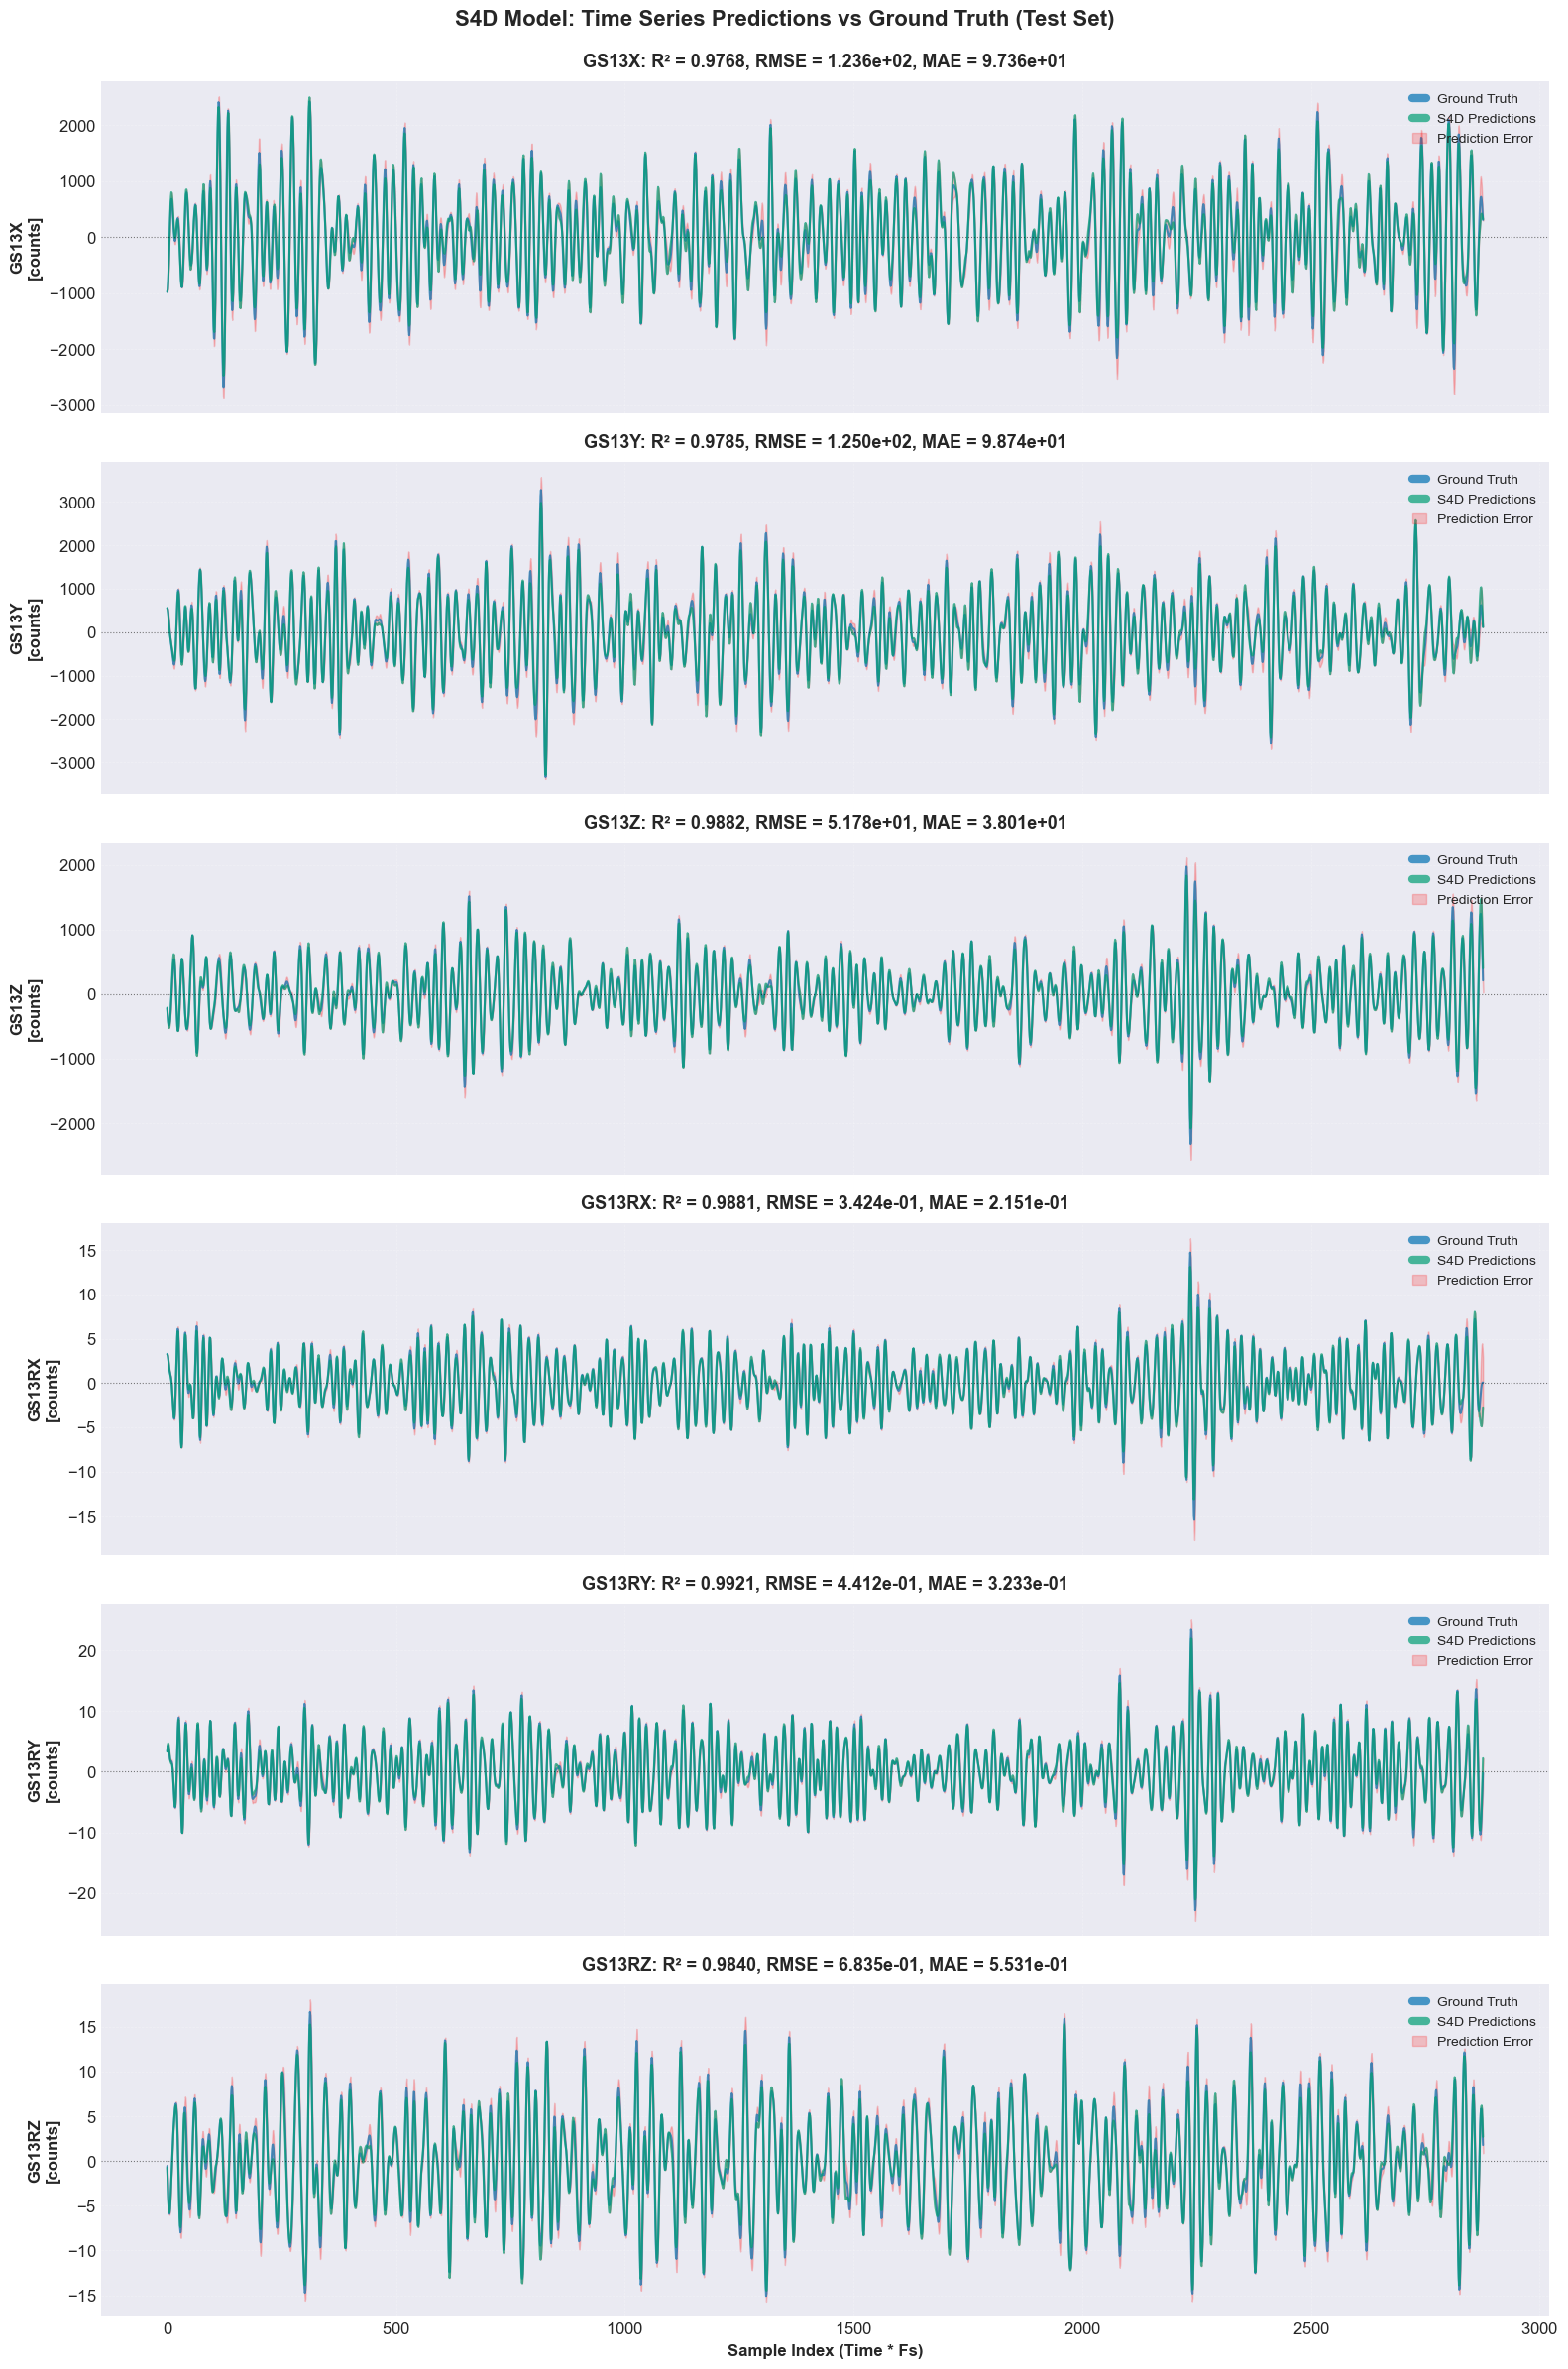

✓ Time series plots complete


In [12]:
print("\n" + "="*70)
print("PLOTTING TIME SERIES PREDICTIONS")
print("(In original physical units)")
print("="*70)

fig, axes = plt.subplots(6, 1, figsize=(16, 24), sharex=True)
fig.suptitle('S4D Model: Time Series Predictions vs Ground Truth (Test Set)', 
             fontsize=16, fontweight='bold', y=0.995)

for i, (ax, name) in enumerate(zip(axes, channel_names)):
    # Get metrics for this channel
    r2_ch = metrics_df.loc[name, 'R²']
    mae_ch = metrics_df.loc[name, 'MAE']
    rmse_ch = metrics_df.loc[name, 'RMSE']
    
    # Plot DENORMALIZED data
    ax.plot(targets[:, i], label='Ground Truth', color='#0072B2', alpha=0.7, linewidth=1.5)
    ax.plot(predictions[:, i], label='S4D Predictions', color='#009E73', alpha=0.7, linewidth=1.5)
    
    # Add error shading
    error = predictions[:, i] - targets[:, i]
    ax.fill_between(range(len(targets)), 
                     targets[:, i] - np.abs(error), 
                     targets[:, i] + np.abs(error), 
                     alpha=0.2, color='red', label='Prediction Error')
    
    ax.set_ylabel(f'{name}\n[counts]', fontsize=12, fontweight='bold')
    ax.set_title(f'{name}: R² = {r2_ch:.4f}, RMSE = {rmse_ch:.3e}, MAE = {mae_ch:.3e}', 
                 fontsize=13, fontweight='bold', pad=10)
    ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add zero line for reference
    ax.axhline(y=0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)

axes[-1].set_xlabel('Sample Index (Time * Fs)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Time series plots complete")
print("="*70)



ERROR ANALYSIS PLOTS


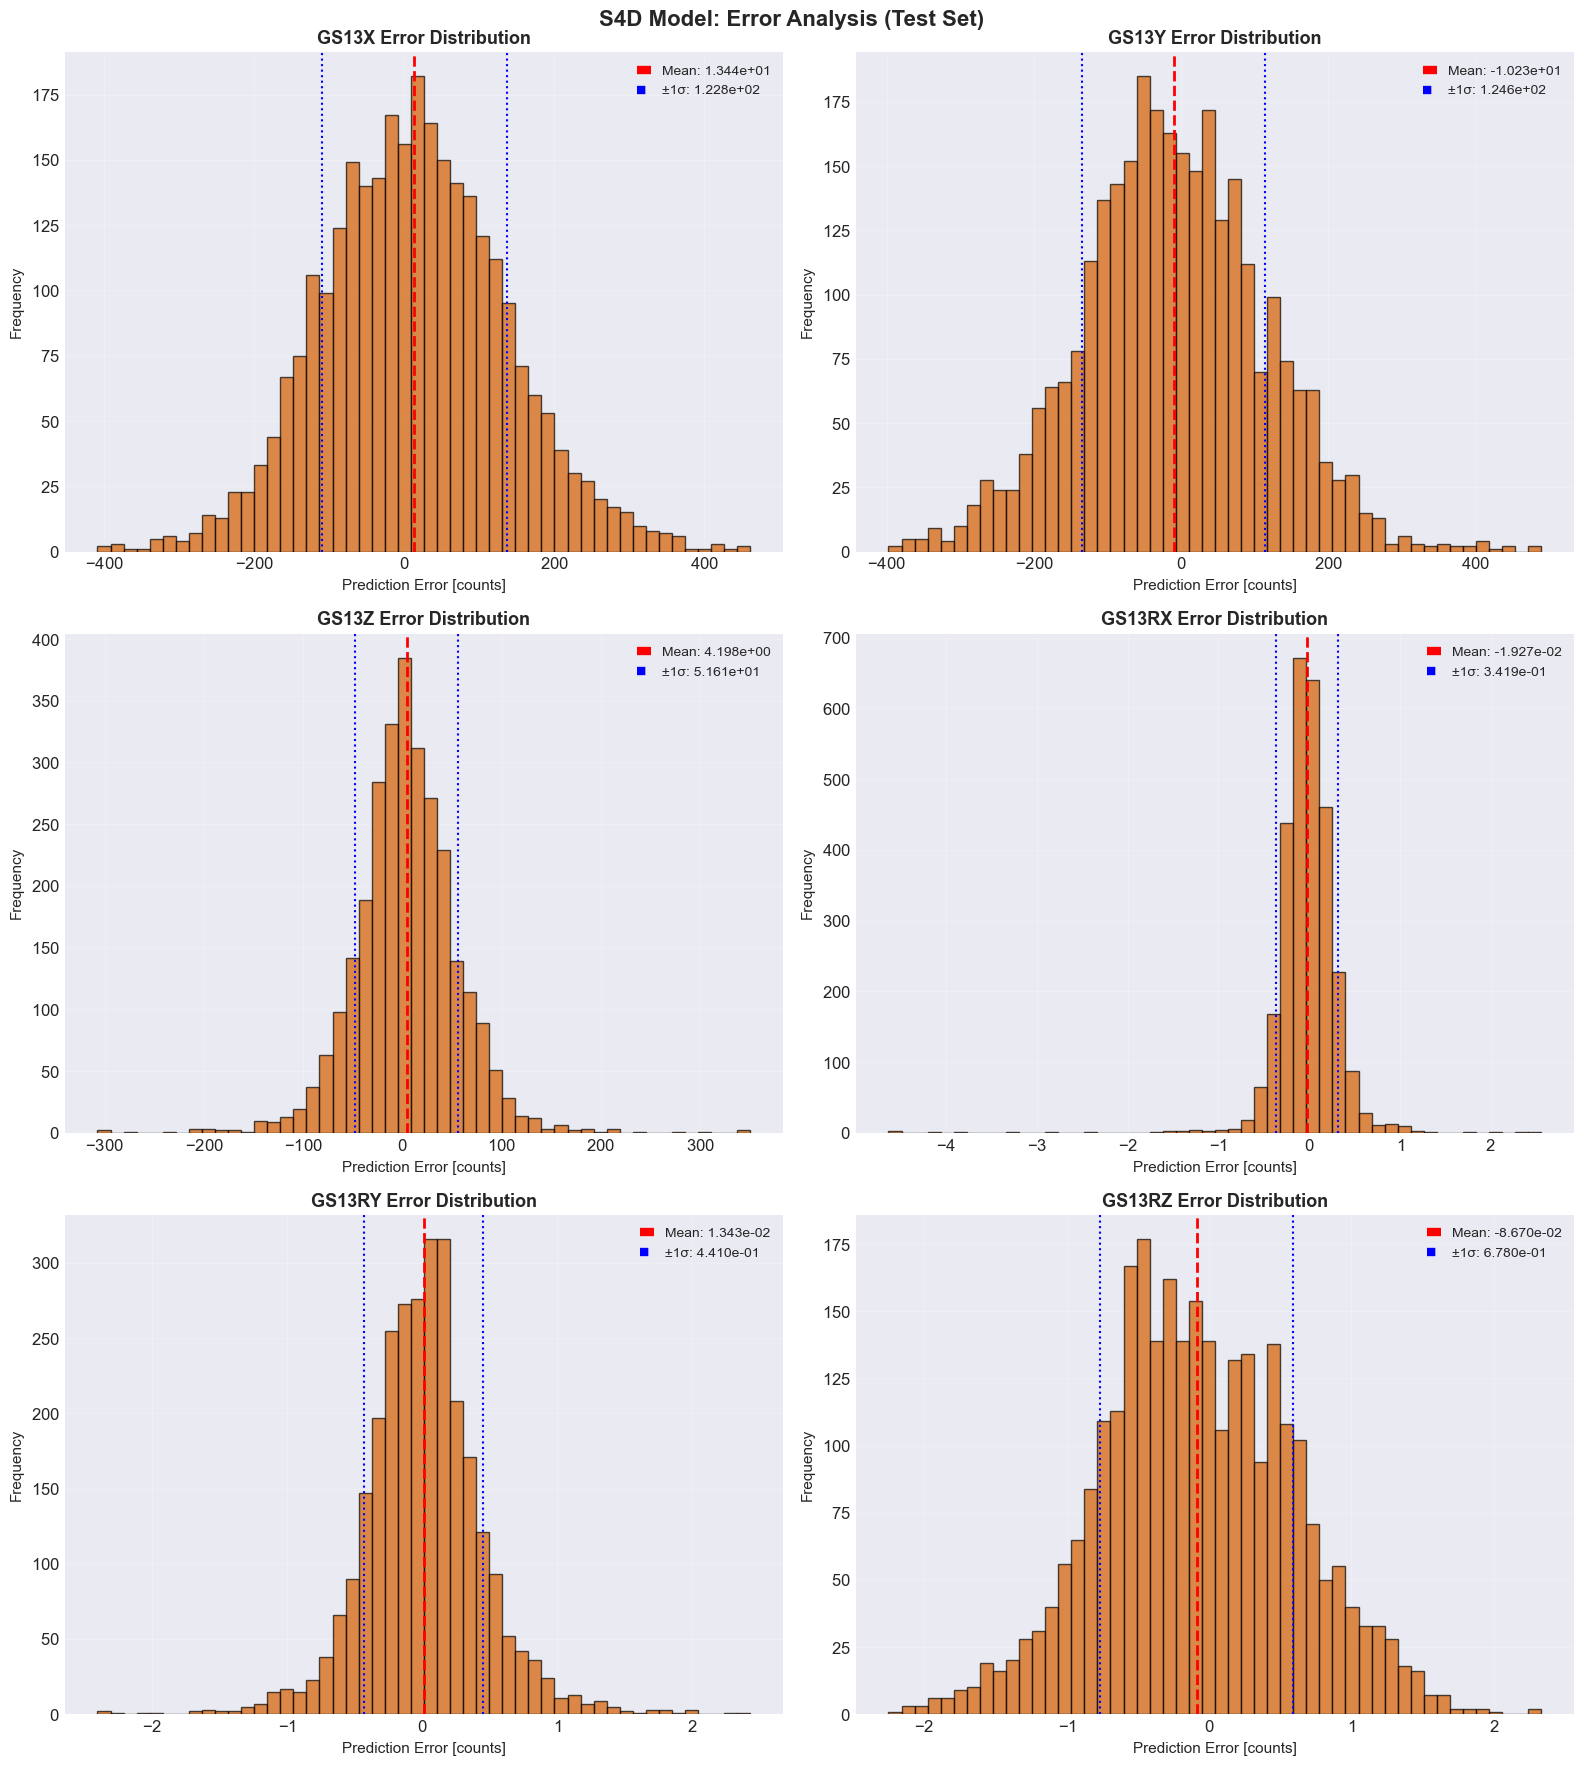

✓ Error analysis plots complete


In [13]:
print("\n" + "="*70)
print("ERROR ANALYSIS PLOTS")
print("="*70)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('S4D Model: Error Analysis (Test Set)', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, channel_names)):
    error = predictions[:, i] - targets[:, i]
    
    # Create histogram of errors
    ax.hist(error, bins=50, alpha=0.7, color='#D55E00', edgecolor='black')
    
    # Add statistics
    mean_error = np.mean(error)
    std_error = np.std(error)
    
    ax.axvline(mean_error, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_error:.3e}')
    ax.axvline(mean_error - std_error, color='blue', linestyle=':', linewidth=1.5,
               label=f'±1σ: {std_error:.3e}')
    ax.axvline(mean_error + std_error, color='blue', linestyle=':', linewidth=1.5)
    
    ax.set_xlabel('Prediction Error [counts]', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{name} Error Distribution', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Error analysis plots complete")
print("="*70)


SCATTER PLOTS: PREDICTIONS VS GROUND TRUTH


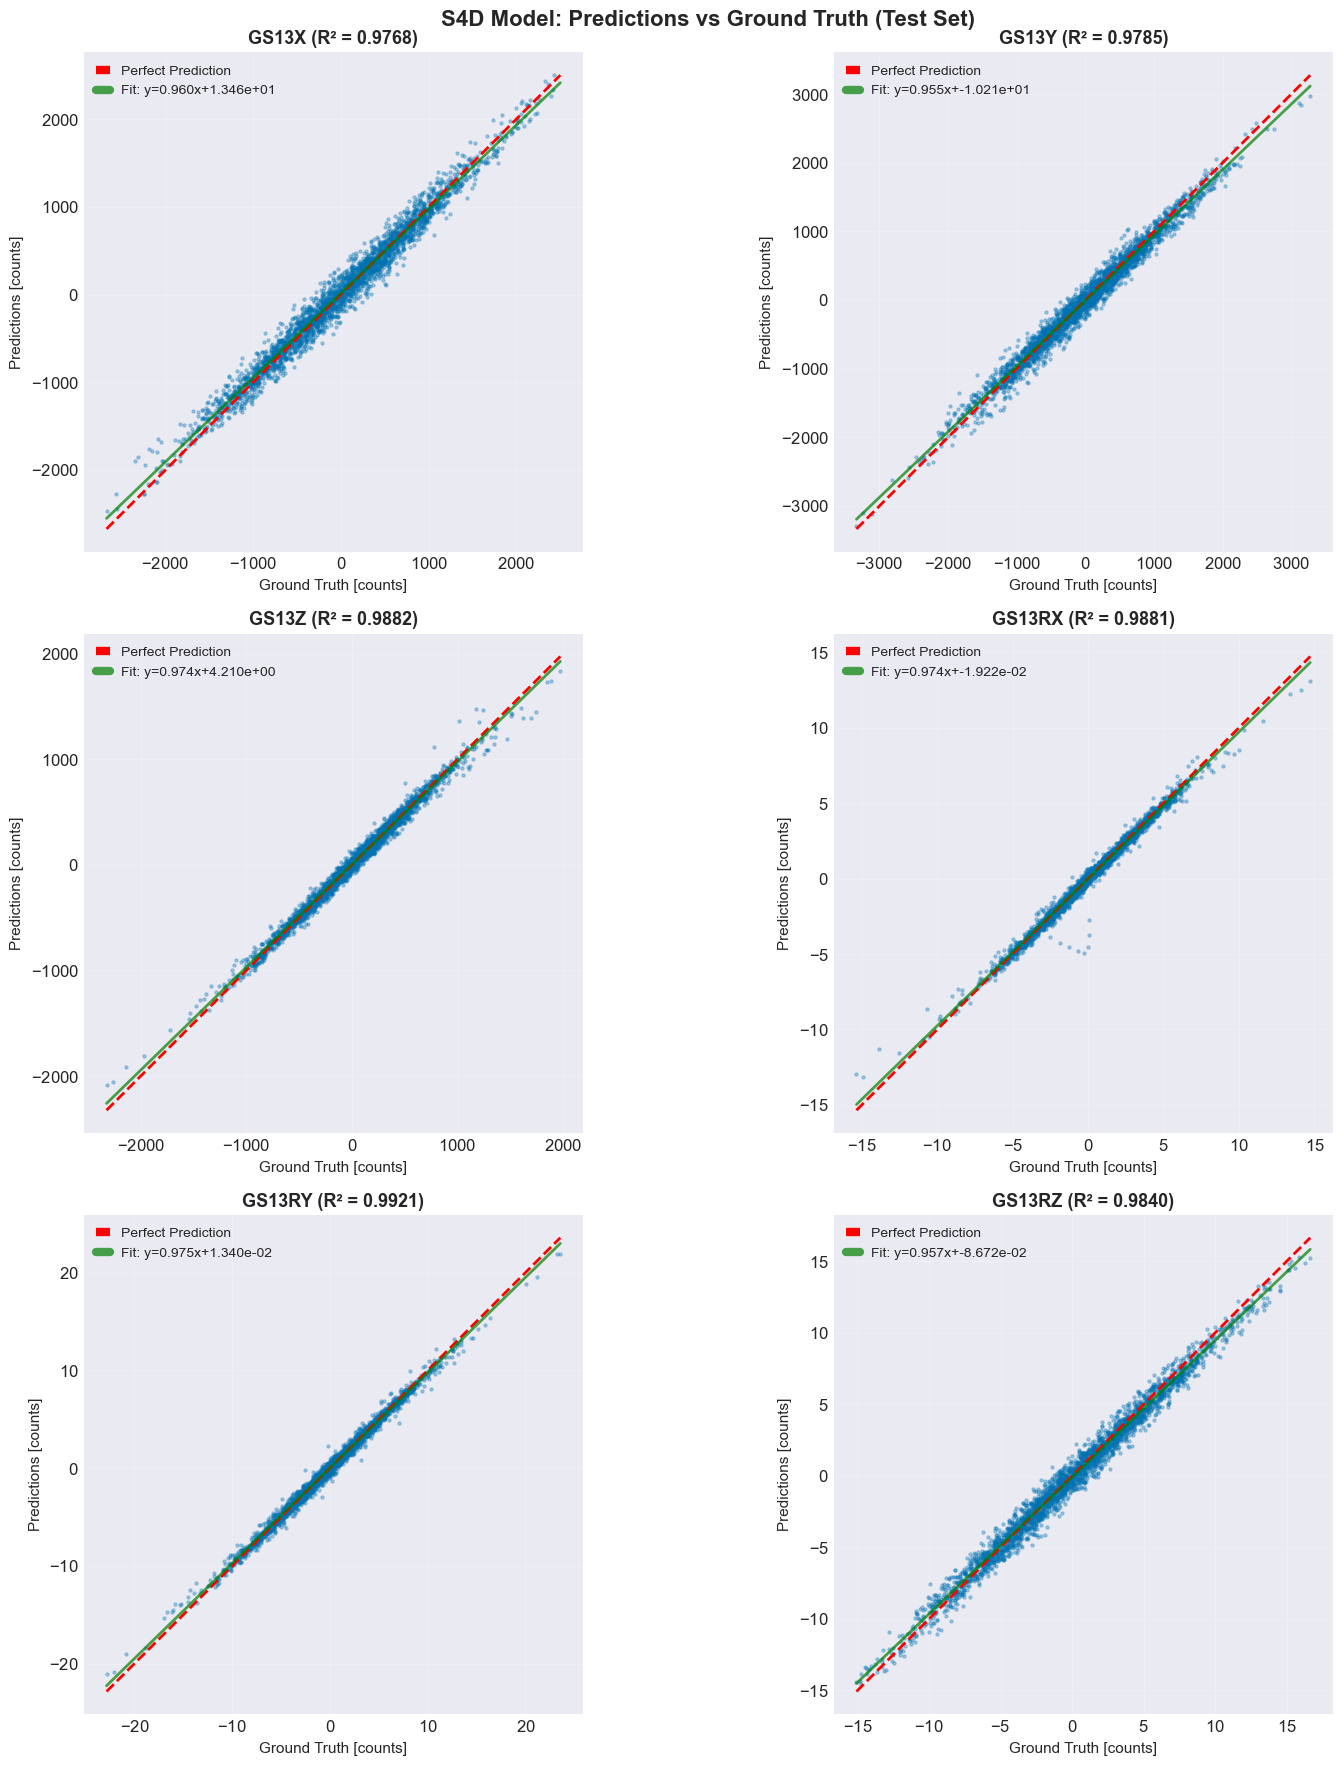

✓ Scatter plots complete


In [14]:
# Cell 12: Visualization - Scatter Plots
# ============================================================================
print("\n" + "="*70)
print("SCATTER PLOTS: PREDICTIONS VS GROUND TRUTH")
print("="*70)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('S4D Model: Predictions vs Ground Truth (Test Set)', 
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, channel_names)):
    # Get data for this channel
    target_ch = targets[:, i]
    pred_ch = predictions[:, i]
    r2_ch = metrics_df.loc[name, 'R²']
    
    # Create scatter plot
    ax.scatter(target_ch, pred_ch, alpha=0.3, s=5, color='#0072B2')
    
    # Add perfect prediction line
    min_val = min(target_ch.min(), pred_ch.min())
    max_val = max(target_ch.max(), pred_ch.max())
    ax.plot([min_val, max_val], [min_val, max_val], 
            'r--', linewidth=2, label='Perfect Prediction')
    
    # Add regression line
    z = np.polyfit(target_ch, pred_ch, 1)
    p = np.poly1d(z)
    ax.plot([min_val, max_val], p([min_val, max_val]), 
            'g-', linewidth=2, alpha=0.7, label=f'Fit: y={z[0]:.3f}x+{z[1]:.3e}')
    
    ax.set_xlabel('Ground Truth [counts]', fontsize=11)
    ax.set_ylabel('Predictions [counts]', fontsize=11)
    ax.set_title(f'{name} (R² = {r2_ch:.4f})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Equal aspect ratio
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print("✓ Scatter plots complete")
print("="*70)


In [15]:
# Cell 13: ASD Analysis - Setup
# ============================================================================
print("\n" + "="*70)
print("AMPLITUDE SPECTRAL DENSITY (ASD) ANALYSIS")
print("(In original physical units)")
print("="*70)
print("This evaluates noise subtraction performance.")
print("The 'Residual' ASD shows the remaining noise after prediction.")
print("-"*70)

# Sampling frequency (from your data config)
sampling_frequency = 4  # Hz (downsampled to 4 Hz)
fftlength = min(1000, predictions.shape[0] // 4)  # Adaptive FFT length
overlap = fftlength // 2

print(f"ASD Parameters:")
print(f"  Sampling Frequency: {sampling_frequency} Hz")
print(f"  FFT length:         {fftlength} samples")
print(f"  Overlap:            {overlap} samples")
print(f"  Frequency range:    [{1/fftlength:.4f}, {sampling_frequency/2}] Hz")
print("="*70)



AMPLITUDE SPECTRAL DENSITY (ASD) ANALYSIS
(In original physical units)
This evaluates noise subtraction performance.
The 'Residual' ASD shows the remaining noise after prediction.
----------------------------------------------------------------------
ASD Parameters:
  Sampling Frequency: 4 Hz
  FFT length:         719 samples
  Overlap:            359 samples
  Frequency range:    [0.0014, 2.0] Hz



COMPUTING AND PLOTTING ASDs
Computing ASD for GS13X... ✓ (Reduction: 19.8 dB)
Computing ASD for GS13Y... ✓ (Reduction: 20.6 dB)
Computing ASD for GS13Z... ✓ (Reduction: 28.7 dB)
Computing ASD for GS13RX... ✓ (Reduction: 32.3 dB)
Computing ASD for GS13RY... ✓ (Reduction: 54.9 dB)
Computing ASD for GS13RZ... ✓ (Reduction: 30.0 dB)


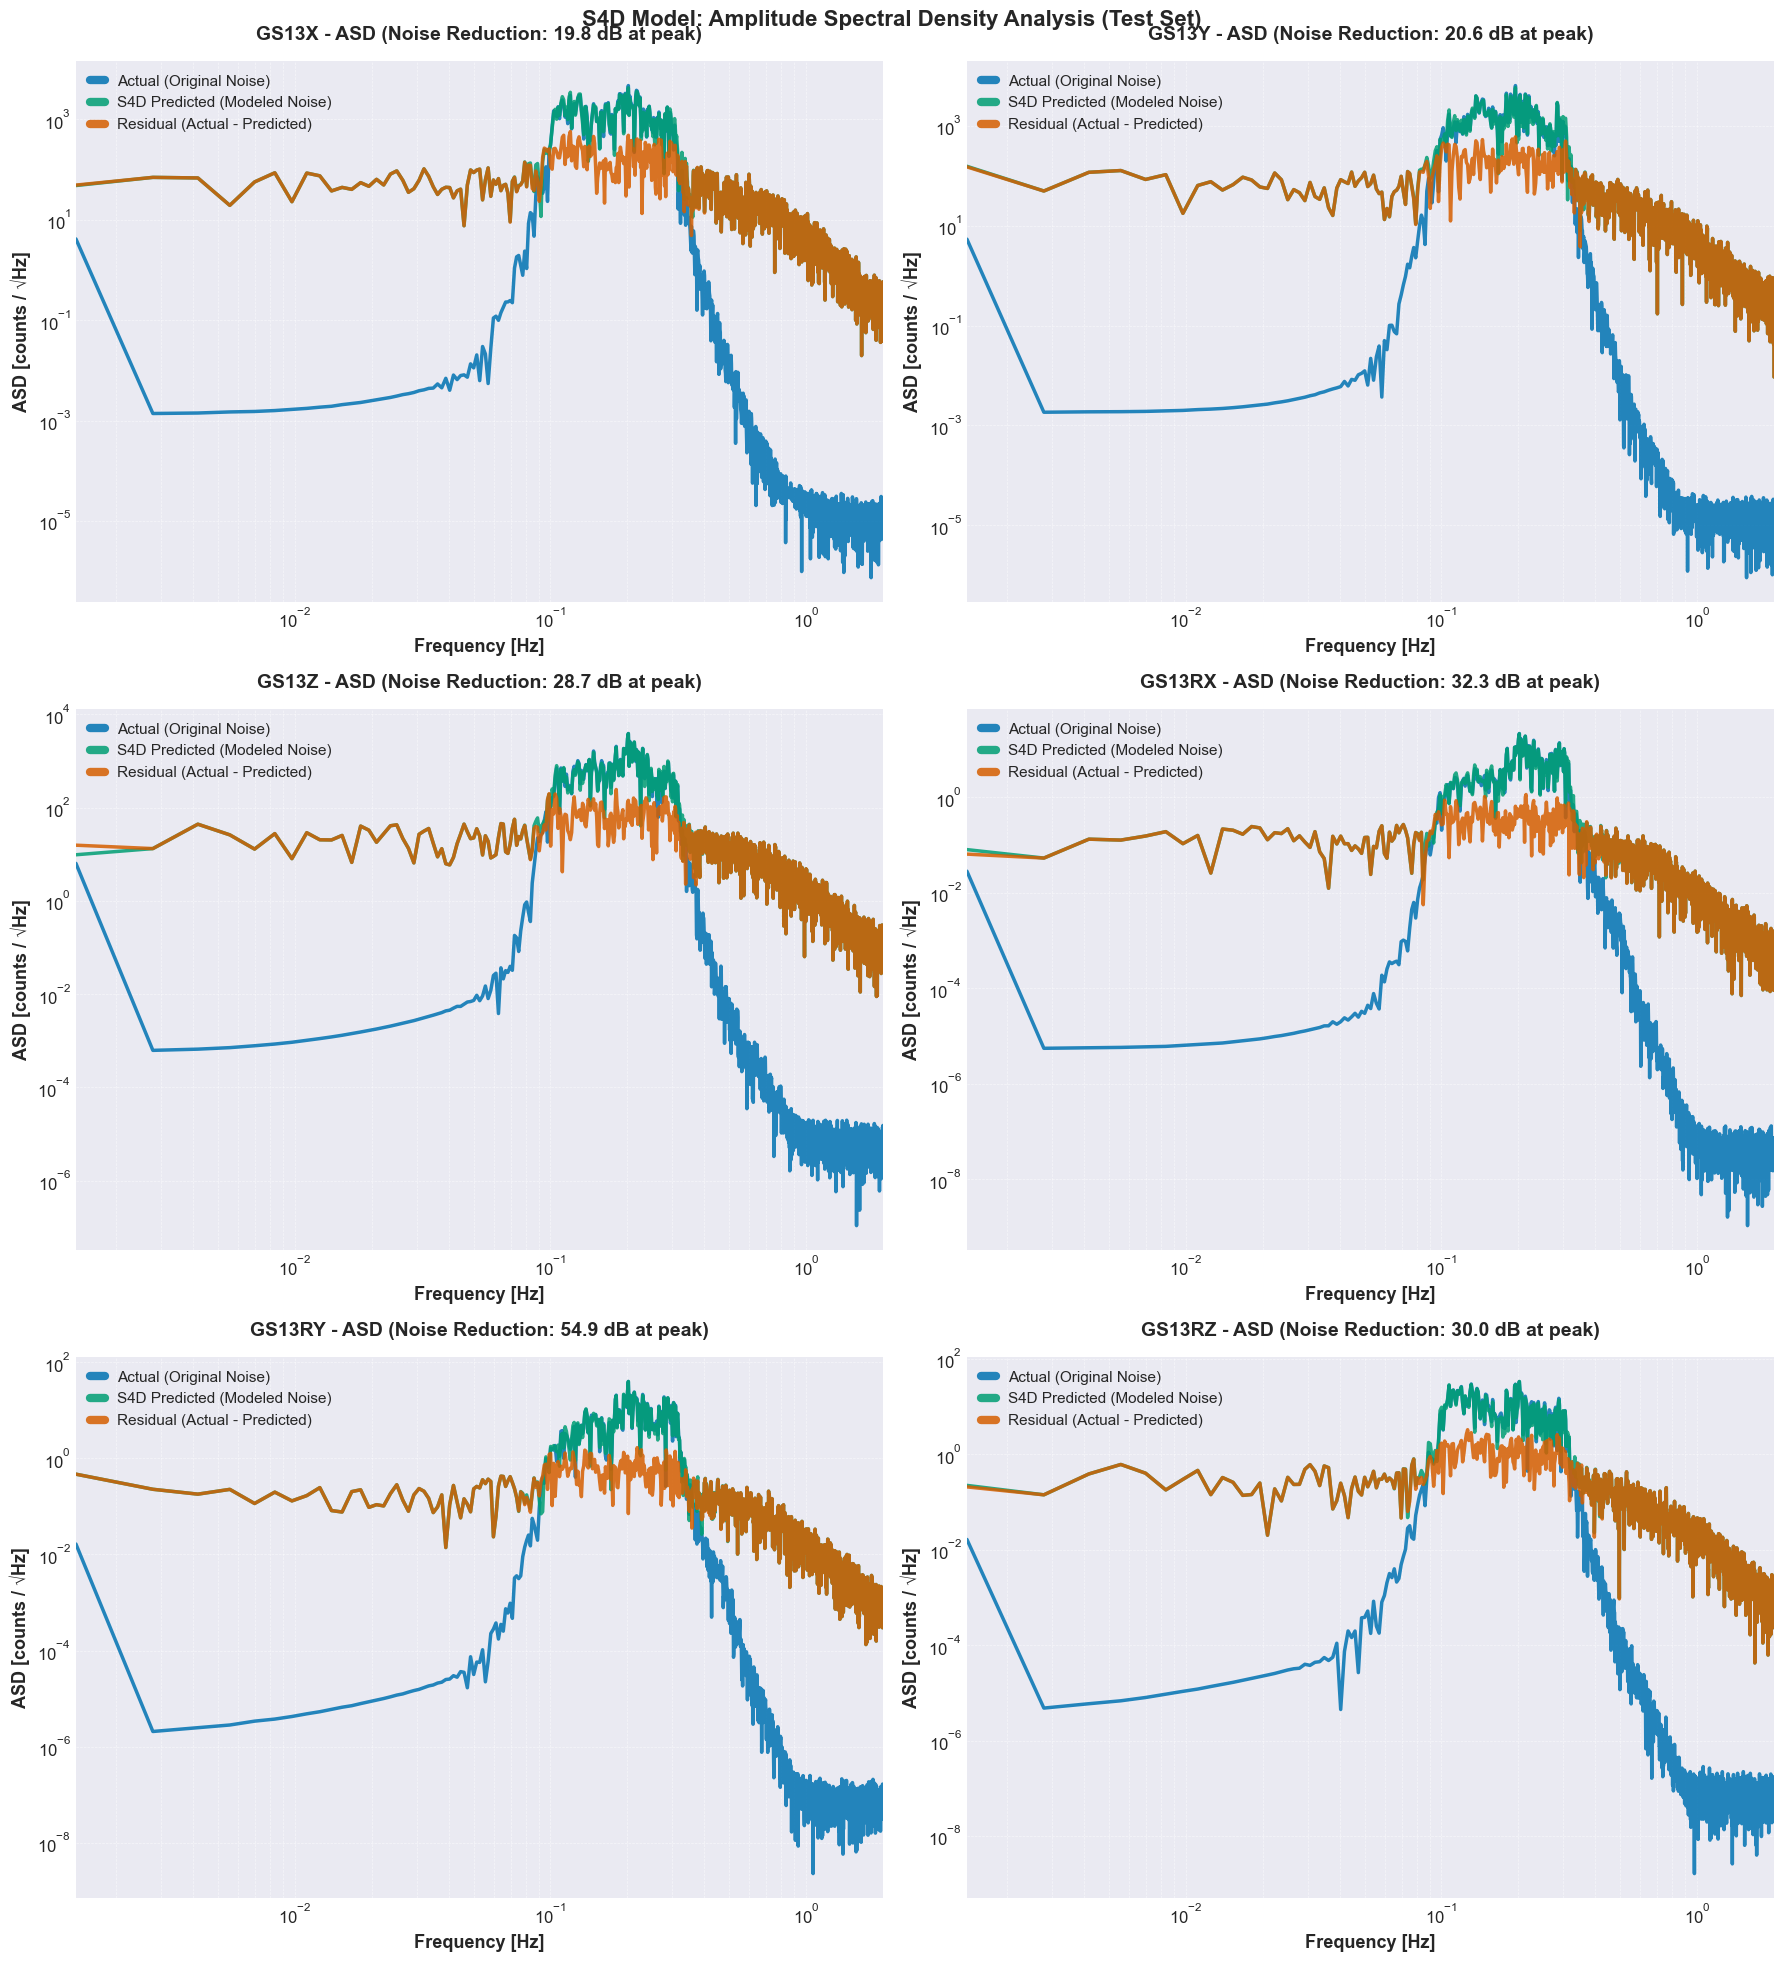


✓ ASD analysis complete!


In [16]:
# Cell 14: ASD Analysis - Computation and Plotting
# ============================================================================
print("\n" + "="*70)
print("COMPUTING AND PLOTTING ASDs")
print("="*70)

# Create a 3x2 grid for ASD plots
fig_asd, axes_asd = plt.subplots(3, 2, figsize=(18, 20))
fig_asd.suptitle('S4D Model: Amplitude Spectral Density Analysis (Test Set)', 
                 fontsize=16, fontweight='bold')
axes_asd = axes_asd.flatten()

for i, (ax, name) in enumerate(zip(axes_asd, channel_names)):
    print(f"Computing ASD for {name}...", end=' ')
    
    # Create TimeSeries objects from the DENORMALIZED data
    ts_actual = TimeSeries(targets[:, i], 
                          sample_rate=sampling_frequency, 
                          name=f'Actual {name}')
    ts_predicted = TimeSeries(predictions[:, i], 
                             sample_rate=sampling_frequency, 
                             name=f'Predicted {name}')
    
    # Residual = Actual - Predicted (this is the noise subtraction)
    ts_residual = TimeSeries(targets[:, i] - predictions[:, i], 
                            sample_rate=sampling_frequency, 
                            name=f'Residual {name}')
    
    # Compute ASDs
    asd_actual = ts_actual.asd(fftlength=fftlength, overlap=overlap)
    asd_predicted = ts_predicted.asd(fftlength=fftlength, overlap=overlap)
    asd_residual = ts_residual.asd(fftlength=fftlength, overlap=overlap)
    
    # Plot all three ASDs
    ax.loglog(asd_actual.frequencies.value, asd_actual.value, 
              label='Actual (Original Noise)', 
              color='#0072B2', linewidth=2.5, alpha=0.85)
    ax.loglog(asd_predicted.frequencies.value, asd_predicted.value, 
              label='S4D Predicted (Modeled Noise)', 
              color='#009E73', linewidth=2.5, alpha=0.85)
    ax.loglog(asd_residual.frequencies.value, asd_residual.value, 
              label='Residual (Actual - Predicted)', 
              color='#D55E00', linewidth=2.5, alpha=0.85)
    
    # Calculate noise reduction ratio at peak
    peak_freq_idx = np.argmax(asd_actual.value)
    peak_actual = asd_actual.value[peak_freq_idx]
    peak_residual = asd_residual.value[peak_freq_idx]
    reduction_db = 20 * np.log10(peak_actual / peak_residual) if peak_residual > 0 else 0
    
    ax.set_xlabel('Frequency [Hz]', fontsize=13, fontweight='bold')
    ax.set_ylabel('ASD [counts / √Hz]', fontsize=13, fontweight='bold')
    ax.set_title(f'{name} - ASD (Noise Reduction: {reduction_db:.1f} dB at peak)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.legend(fontsize=11, loc='best', framealpha=0.9)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
    ax.set_xlim(asd_actual.frequencies.value[1], sampling_frequency/2)
    
    print(f"✓ (Reduction: {reduction_db:.1f} dB)")

plt.tight_layout()
plt.show()

print("\n✓ ASD analysis complete!")
print("="*70)

In [19]:
# Cell 15: Summary Statistics
# ============================================================================
print("\n" + "="*70)
print("FINAL SUMMARY STATISTICS")
print("="*70)

print("\nBest and Worst Performing Channels:")
print("-"*70)

# Sort by R²
sorted_by_r2 = metrics_df.sort_values('R²', ascending=False)
print("\nBy R² Score (best to worst):")
for idx, (channel, row) in enumerate(sorted_by_r2.iterrows(), 1):
    print(f"  {idx}. {channel:8s}: R² = {row['R²']:.4f}, RMSE = {row['RMSE']:.3e}")

# Sort by RMSE
sorted_by_rmse = metrics_df.sort_values('RMSE', ascending=True)
print("\nBy RMSE (best to worst):")
for idx, (channel, row) in enumerate(sorted_by_rmse.iterrows(), 1):
    print(f"  {idx}. {channel:8s}: RMSE = {row['RMSE']:.3e}, R² = {row['R²']:.4f}")

print("\n" + "-"*70)
print("Average Performance Across All Channels:")
print("-"*70)
print(f"  Mean R²:          {metrics_df['R²'].mean():.4f}")
print(f"  Mean RMSE:        {metrics_df['RMSE'].mean():.3e}")
print(f"  Mean MAE:         {metrics_df['MAE'].mean():.3e}")
print(f"  Mean Correlation: {metrics_df['Correlation'].mean():.4f}")
print(f"  Mean Rel. MAE:    {metrics_df['Rel. MAE (%)'].mean():.2f}%")

print("\n" + "="*70)
print("EVALUATION COMPLETE!")
print("="*70)
print("\nS4D Model Test Set Evaluation Summary:")
print(f"  • Total test samples: {len(targets)}")
print(f"  • Device used:        {device}")
print(f"  • Model checkpoint:   {Path(CHECKPOINT).name}")
print("="*70)


FINAL SUMMARY STATISTICS

Best and Worst Performing Channels:
----------------------------------------------------------------------

By R² Score (best to worst):
  1. GS13RY  : R² = 0.9921, RMSE = 4.412e-01
  2. GS13Z   : R² = 0.9882, RMSE = 5.178e+01
  3. GS13RX  : R² = 0.9881, RMSE = 3.424e-01
  4. GS13RZ  : R² = 0.9840, RMSE = 6.835e-01
  5. GS13Y   : R² = 0.9785, RMSE = 1.250e+02
  6. GS13X   : R² = 0.9768, RMSE = 1.236e+02

By RMSE (best to worst):
  1. GS13RX  : RMSE = 3.424e-01, R² = 0.9881
  2. GS13RY  : RMSE = 4.412e-01, R² = 0.9921
  3. GS13RZ  : RMSE = 6.835e-01, R² = 0.9840
  4. GS13Z   : RMSE = 5.178e+01, R² = 0.9882
  5. GS13X   : RMSE = 1.236e+02, R² = 0.9768
  6. GS13Y   : RMSE = 1.250e+02, R² = 0.9785

----------------------------------------------------------------------
Average Performance Across All Channels:
----------------------------------------------------------------------
  Mean R²:          0.9846
  Mean RMSE:        5.030e+01
  Mean MAE:         3.920e+01